# TDCSophiread Clustering and Visualization


## 1. Setup and Import

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import tdcsophiread as tdc

print(f"TDCSophiread version: {tdc.__version__}")
print(f"Numpy version: {np.__version__}")

# Setup plotting
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

TDCSophiread version: 3.1.3
Numpy version: 2.3.3


/Users/uff/ORNL Dropbox/Fumiaki Funama/Research/Experiments/Cycle513/mcpevent2hist/sophiread/.pixi/envs/default/lib/python3.13/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 2. Data File Setup

In [2]:
# Ni powder file path
data_path = "/Users/uff/ORNL Dropbox/Fumiaki Funama/Research/Experiments/Cycle513/Data/BothNECL-plate-MCP/Efficiency/"
ni_file = "/Users/uff/ORNL Dropbox/Fumiaki Funama/Research/Experiments/Cycle513/Data/BothNECL-plate-MCP/Transmission/Linepair_1800V_1100V_500V_300s000000.tpx3"
ni_full_path = os.path.join(data_path, ni_file)

# Verify file exists
if os.path.exists(ni_full_path):
    size_mb = os.path.getsize(ni_full_path) / (1024 * 1024)
    print(f"✅ Ni powder file found: {ni_file}")
    print(f"   Size: {size_mb:.1f} MB")
else:
    print(f"❌ File not found: {ni_full_path}")
    print("Please ensure the data file is in the correct location")

✅ Ni powder file found: /Users/uff/ORNL Dropbox/Fumiaki Funama/Research/Experiments/Cycle513/Data/BothNECL-plate-MCP/Transmission/Linepair_1800V_1100V_500V_300s000000.tpx3
   Size: 3880.3 MB


## 3. Raw Data → Hits Processing

In [3]:
print("=== Processing TPX3 file to hits ===")

start_time = time.time()

# Process the file using TDCSophiread (high-level convenience function)
# NEW: Returns TDCHitView for zero-copy numpy access
hit_view = tdc.process_tpx3(ni_full_path, parallel=True)

# Convert to numpy array (zero-copy)
hits = np.array(hit_view, copy=False)

processing_time = time.time() - start_time

print(f"✅ Processing completed in {processing_time:.2f} seconds")
print(f"✅ Total hits extracted: {len(hits):,}")
print(f"✅ Processing rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")

# Display hit data structure
print("\nHit data structure:")
for field in hits.dtype.names:
    array = hits[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    print(f"    range: {array.min()} - {array.max()}")

=== Processing TPX3 file to hits ===
✅ Processing completed in 14.07 seconds
✅ Total hits extracted: 507,125,118
✅ Processing rate: 36.0 M hits/second

Hit data structure:
  tof: uint32, shape (507125118,)
    range: 0 - 1999878
  x: uint16, shape (507125118,)
    range: 0 - 513
  y: uint16, shape (507125118,)
    range: 0 - 513
  timestamp: uint32, shape (507125118,)
    range: 45627 - 1075578703
  tot: uint16, shape (507125118,)
    range: 0 - 1022
  chip_id: uint8, shape (507125118,)
    range: 0 - 3
  cluster_id: int32, shape (507125118,)
    range: -1 - -1


In [4]:
# tot_ns = hits["tot"][:]
#         # ftoa_ns = h5f["ftoa_ns"][:]
# spidertime_ns = hits["timestamp"][:]
# cluster_id = hits["cluster_id"][:]

# print("Unique hit cluster_id (sample):", np.unique(hits["cluster_id"])[:10])
# # show first 20 cluster_id values to inspect
# print(hits["cluster_id"][:200])

In [5]:
print("=== Setting up clustering configuration ===")

# Create neutron processing configuration with VENUS defaults
config = tdc.NeutronProcessingConfig.venus_defaults()
config.extraction.min_tot_threshold = 0
config.temporal.enable_deduplication = False

## No super resolution
config.extraction.super_resolution_factor=1

print("VENUS default neutron processing configuration:")
print(f"  Clustering algorithm: {config.clustering.algorithm}")
print(f"  Extraction algorithm: {config.extraction.algorithm}")

print("\nABS clustering parameters:")
print(f"  Spatial radius: {config.clustering.abs.radius} pixels")
print(f"  Min cluster size: {config.clustering.abs.min_cluster_size} hits")
print(f"  Time range: {config.clustering.abs.neutron_correlation_window} ns")

print("\nCentroid extraction parameters:")
print(f"  Super resolution: {config.extraction.super_resolution_factor}x")
print(f"  TOT weighted: {config.extraction.weighted_by_tot}")
print(f"  Min TOT threshold: {config.extraction.min_tot_threshold}")

print("\nTemporal processing parameters:")
print(f"  Number of workers: {config.temporal.num_workers}")
print(f"  Min batch size: {config.temporal.min_batch_size}")
print(f"  Max batch size: {config.temporal.max_batch_size}")

=== Setting up clustering configuration ===
VENUS default neutron processing configuration:
  Clustering algorithm: abs
  Extraction algorithm: simple_centroid

ABS clustering parameters:
  Spatial radius: 5.0 pixels
  Min cluster size: 1 hits
  Time range: 75.0 ns

Centroid extraction parameters:
  Super resolution: 1.0x
  TOT weighted: True
  Min TOT threshold: 0

Temporal processing parameters:
  Number of workers: 0
  Min batch size: 1000
  Max batch size: 100000


## 5. Hits → Neutrons Clustering

In [6]:
print("=== Clustering hits to neutrons ===")
print(f"Input: {len(hits):,} hits")

start_time = time.time()

# Process hits to neutrons using the new zero-copy interface
# This function accepts both numpy arrays and TDCHitView
neutron_view = tdc.process_hits_to_neutrons(hits, config)

clustering_time = time.time() - start_time

print(f"✅ Clustering completed in {clustering_time:.2f} seconds")

=== Clustering hits to neutrons ===
Input: 507,125,118 hits
✅ Clustering completed in 28.77 seconds


In [7]:
print("Exposing neutron data as numpy array for zero-copy access")
start_time = time.time()
# Convert to numpy array (zero-copy)
neutrons = np.array(neutron_view, copy=False)
processing_time = time.time() - start_time
print(f"✅ Neutron data exposed in {processing_time:.2f} seconds")
print(f"✅ Output neutrons: {len(neutrons):,}")
print(f"✅ Clustering rate: {len(hits) / clustering_time:.0f} hits/second")


Exposing neutron data as numpy array for zero-copy access
✅ Neutron data exposed in 0.00 seconds
✅ Output neutrons: 83,145,946
✅ Clustering rate: 17626707 hits/second


In [8]:
# Calculate clustering efficiency
efficiency = len(neutrons) / len(hits)
print(f"✅ Neutron extraction efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")

# Display neutron data structure
print("\nNeutron data structure:")
for field in neutrons.dtype.names:
    array = neutrons[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    if field in ["x", "y"]:
        print(f"    range: {array.min():.2f} - {array.max():.2f} (sub-pixel)")
    else:
        print(f"    range: {array.min()} - {array.max()}")

✅ Neutron extraction efficiency: 0.163955 (16.3955%)

Neutron data structure:
  x: float64, shape (83145946,)
    range: 0.00 - 513.00 (sub-pixel)
  y: float64, shape (83145946,)
    range: 0.00 - 513.00 (sub-pixel)
  tof: uint32, shape (83145946,)
    range: 0 - 1999878
  tot: uint16, shape (83145946,)
    range: 0 - 21646
  n_hits: uint16, shape (83145946,)
    range: 1 - 1034
  chip_id: uint8, shape (83145946,)
    range: 0 - 3
  reserved: uint8, shape (83145946,)
    range: 0 - 0


## 6. Clustering Results Analysis

In [9]:
print("=== Clustering Results Analysis ===")

# Get neutron fields directly (now it's a structured numpy array)
n_hits_field = neutrons["n_hits"]
x_field = neutrons["x"]
y_field = neutrons["y"]

tot_ns = hits["tot"][:]
        # ftoa_ns = h5f["ftoa_ns"][:]
spidertime_ns = hits["timestamp"][:]
cluster_id = hits["cluster_id"][:]

# Cluster size distribution
cluster_sizes, counts = np.unique(n_hits_field, return_counts=True)
print(f"\nCluster size distribution (showing first 10):")
for size, count in zip(cluster_sizes[:10], counts[:10]):
    percentage = 100 * count / len(neutrons)
    print(f"  {size} hits: {count:,} neutrons ({percentage:.2f}%)")

if len(cluster_sizes) > 10:
    print(f"  ... (total {len(cluster_sizes)} different cluster sizes)")

# Single vs multi-hit clusters
single_hit = counts[cluster_sizes == 1][0] if 1 in cluster_sizes else 0
multi_hit = len(neutrons) - single_hit
print(f"\nCluster composition:")
print(
    f"  Single-hit neutrons: {single_hit:,} ({100 * single_hit / len(neutrons):.1f}%)"
)
print(f"  Multi-hit neutrons: {multi_hit:,} ({100 * multi_hit / len(neutrons):.1f}%)")
print(f"  Mean cluster size: {n_hits_field.mean():.1f} hits")

# Sub-pixel precision check
x_fractional = x_field - np.floor(x_field)
y_fractional = y_field - np.floor(y_field)
non_integer_x = np.sum(x_fractional > 0.001)
non_integer_y = np.sum(y_fractional > 0.001)

print(f"\nSub-pixel precision:")
print(
    f"  Non-integer X coordinates: {non_integer_x:,} ({100 * non_integer_x / len(neutrons):.1f}%)"
)
print(
    f"  Non-integer Y coordinates: {non_integer_y:,} ({100 * non_integer_y / len(neutrons):.1f}%)"
)
print(f"  X fractional range: {x_fractional.min():.3f} - {x_fractional.max():.3f}")
print(f"  Y fractional range: {y_fractional.min():.3f} - {y_fractional.max():.3f}")

=== Clustering Results Analysis ===

Cluster size distribution (showing first 10):
  1 hits: 53,527,046 neutrons (64.38%)
  2 hits: 2,113,018 neutrons (2.54%)
  3 hits: 1,409,181 neutrons (1.69%)
  4 hits: 2,071,362 neutrons (2.49%)
  5 hits: 1,195,087 neutrons (1.44%)
  6 hits: 1,465,387 neutrons (1.76%)
  7 hits: 1,398,414 neutrons (1.68%)
  8 hits: 1,306,107 neutrons (1.57%)
  9 hits: 1,335,671 neutrons (1.61%)
  10 hits: 1,202,203 neutrons (1.45%)
  ... (total 620 different cluster sizes)

Cluster composition:
  Single-hit neutrons: 53,527,046 (64.4%)
  Multi-hit neutrons: 29,618,900 (35.6%)
  Mean cluster size: 6.1 hits

Sub-pixel precision:
  Non-integer X coordinates: 28,164,122 (33.9%)
  Non-integer Y coordinates: 28,453,242 (34.2%)
  X fractional range: 0.000 - 1.000
  Y fractional range: 0.000 - 1.000


## 7. Spatial Distribution Visualization

In [10]:
det_venus_config = tdc.DetectorConfig.venus_defaults()

det_venus_config.get_chip_size_x(), det_venus_config.get_chip_size_y()

(256, 256)

=== Creating spatial distribution visualizations ===

Creating hits 2D histogram...
Creating neutrons 2D histogram...


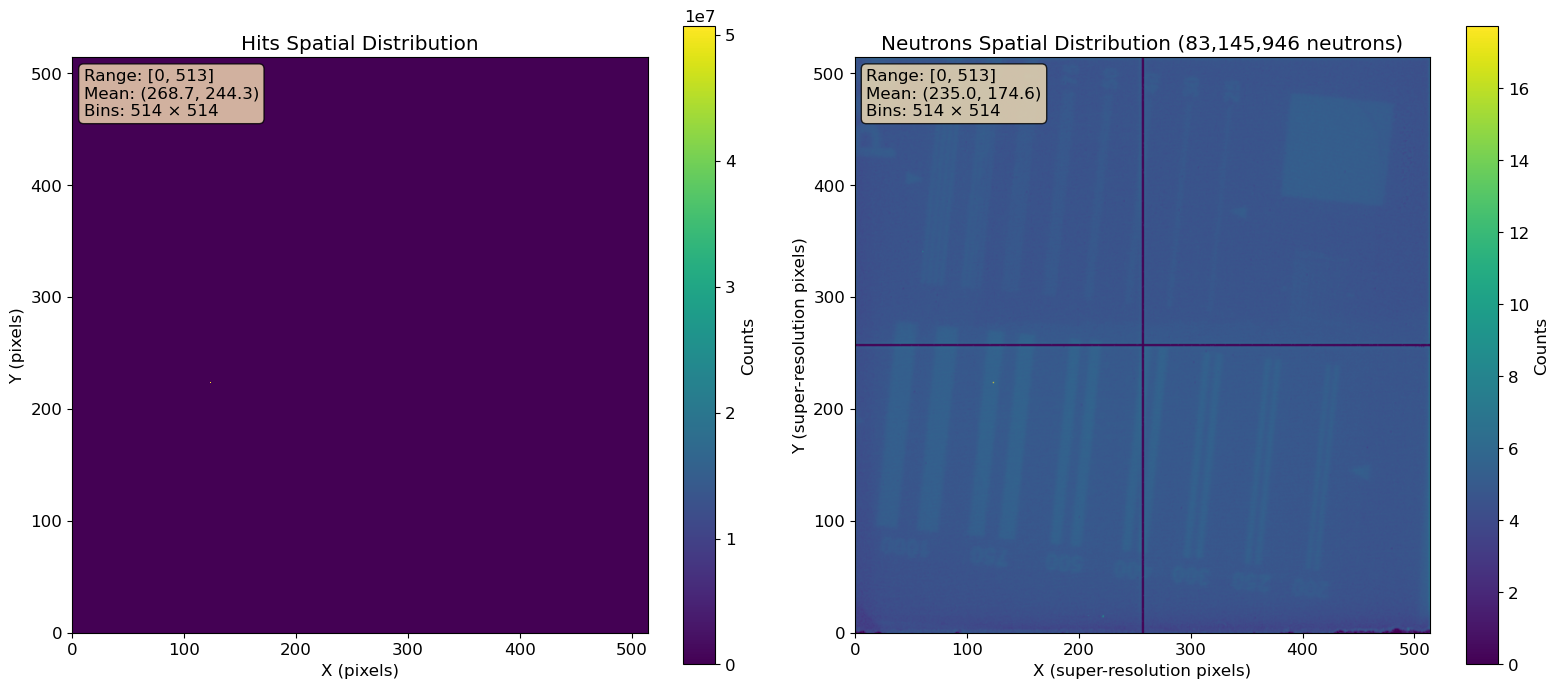


=== Spatial Distribution Analysis ===
Detector configuration: 514×514 pixels
Super-resolution factor: 1.0x

Hits (native pixels):
  X range: 0 - 513
  Y range: 0 - 513
  Total hits: 507,125,118

Neutrons (super-resolution pixels):
  X range: 0.0 - 513.0
  Y range: 0.0 - 513.0
  Total neutrons: 83,145,946
  Data reduction: 6.1:1


In [11]:
print("=== Creating spatial distribution visualizations ===")

# VENUS detector has 514x514 pixels (256*2 + 2 pixel gap)
DETECTOR_PIXELS = det_venus_config.get_chip_size_x() * 2 + 2

# use super-resolution factor from config
NEUTRON_SUPER_RES = config.extraction.super_resolution_factor

# Create figure with two subplots for better comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Hits distribution (native pixels)
print("\nCreating hits 2D histogram...")
# Sample hits for performance
# sample_size = 500_000
# indices = np.random.choice(len(hits), sample_size, replace=False)
hits_x_sample = hits["x"]
hits_y_sample = hits["y"]

# Use 514 bins for native pixel data (one bin per detector pixel)
hist_hits, x_edges, y_edges = np.histogram2d(
    hits_x_sample,
    hits_y_sample,
    bins=DETECTOR_PIXELS,
    range=[[0, DETECTOR_PIXELS], [0, DETECTOR_PIXELS]],
)

im1 = ax1.imshow(
    hist_hits,
    origin="lower",
    aspect="equal",
    extent=[0, DETECTOR_PIXELS, 0, DETECTOR_PIXELS],
    cmap="viridis",
    interpolation="none",
)
ax1.set_xlabel("X (pixels)")
ax1.set_ylabel("Y (pixels)")
ax1.set_title(f"Hits Spatial Distribution")
plt.colorbar(im1, ax=ax1, label="Counts")

# Add statistics
stats_text = f"Range: [{hits_x_sample.min()}, {hits_x_sample.max()}]\n"
stats_text += f"Mean: ({hits_x_sample.mean():.1f}, {hits_y_sample.mean():.1f})\n"
stats_text += f"Bins: {DETECTOR_PIXELS} × {DETECTOR_PIXELS}"
ax1.text(
    0.02,
    0.98,
    stats_text,
    transform=ax1.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Neutrons distribution (super-resolution pixels)
print("Creating neutrons 2D histogram...")
# Use detector and clustering configuration to determine bins
NEUTRON_BINS = int(DETECTOR_PIXELS * NEUTRON_SUPER_RES)
neutrons_x = neutrons["x"]
neutrons_y = neutrons["y"]
x_min, x_max = neutrons_x.min(), neutrons_x.max()
y_min, y_max = neutrons_y.min(), neutrons_y.max()

hist_neutrons, x_edges_n, y_edges_n = np.histogram2d(
    neutrons_x,
    neutrons_y,
    bins=NEUTRON_BINS,
    range=[[0, NEUTRON_BINS], [0, NEUTRON_BINS]],
    # range=[[x_min, x_max], [y_min, y_max]],
)

im2 = ax2.imshow(
    np.log1p(hist_neutrons),
    origin="lower",
    aspect="equal",
    extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
    # extent=[x_min, x_max, y_min, y_max],
    cmap="viridis",
    interpolation="gaussian",  # this is critical when we have too many 1 hit neutrons
)
ax2.set_xlabel("X (super-resolution pixels)")
ax2.set_ylabel("Y (super-resolution pixels)")
ax2.set_title(f"Neutrons Spatial Distribution ({len(neutrons):,} neutrons)")
plt.colorbar(im2, ax=ax2, label="Counts")

# Add statistics
stats_text = f"Range: [{neutrons_x.min():.0f}, {neutrons_x.max():.0f}]\n"
stats_text += f"Mean: ({neutrons_x.mean():.1f}, {neutrons_y.mean():.1f})\n"
stats_text += f"Bins: {NEUTRON_BINS} × {NEUTRON_BINS}"
ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n=== Spatial Distribution Analysis ===")
print(f"Detector configuration: {DETECTOR_PIXELS}×{DETECTOR_PIXELS} pixels")
print(f"Super-resolution factor: {NEUTRON_SUPER_RES}x")

print("\nHits (native pixels):")
print(f"  X range: {hits['x'].min()} - {hits['x'].max()}")
print(f"  Y range: {hits['y'].min()} - {hits['y'].max()}")
print(f"  Total hits: {len(hits):,}")

print("\nNeutrons (super-resolution pixels):")
print(f"  X range: {neutrons_x.min():.1f} - {neutrons_x.max():.1f}")
print(f"  Y range: {neutrons_y.min():.1f} - {neutrons_y.max():.1f}")
print(f"  Total neutrons: {len(neutrons):,}")
print(f"  Data reduction: {len(hits) / len(neutrons):.1f}:1")

In [12]:
# Verify cluster ID counts
unique_cluster_ids = np.unique(hits['cluster_id'][hits['cluster_id'] >= 0])  # exclude -1 (unclustered)
n_unique_clusters = len(unique_cluster_ids)
n_neutrons = len(neutrons)
n_hits = len(hits)

print(f"Total hits: {n_hits:,}")
print(f"Unique cluster IDs: {n_unique_clusters:,}")
print(f"Total neutrons: {n_neutrons:,}")
print(f"Match: {n_unique_clusters == n_neutrons}")
print(f"\nHits per neutron (average): {n_hits / n_neutrons:.2f}")

Total hits: 507,125,118
Unique cluster IDs: 46,772,838
Total neutrons: 83,145,946
Match: False

Hits per neutron (average): 6.10


## 8. Process Open Beam Data

In [13]:
# Store linepair data
linepair_neutrons = neutrons.copy()
linepair_hist = hist_neutrons.copy()

# Define Open Beam file
# ob_file = "OB_1800_1100_500V_5mins000000.tpx3"
ob_full_path = "/Users/uff/ORNL Dropbox/Fumiaki Funama/Research/Experiments/Cycle513/Data/BothNECL-plate-MCP/Transmission/OB_1800V_1100V_500V_300s000000.tpx3"

# print(f"Open Beam file: {ob_file}")
# print(f"Full path: {ob_full_path}")

# Check file existence
if os.path.exists(ob_full_path):
    size_mb = os.path.getsize(ob_full_path) / (1024 * 1024)
    print(f"✅ File exists: {size_mb:.2f} MB")
else:
    print("❌ File not found!")

✅ File exists: 7898.03 MB


In [14]:
# Process Open Beam TPX3 file
# print(f"=== Processing Open Beam TPX3 file: {ob_file} ===")

start_time = time.time()
ob_hit_view = tdc.process_tpx3(ob_full_path, parallel=True)
processing_time = time.time() - start_time

# print(f"✅ Processed in {processing_time:.2f} seconds")
# print(f"✅ Detected {len(ob_hit_view):,} hits")
# print(f"✅ Processing rate: {len(ob_hit_view) / processing_time:.0f} hits/second")

In [15]:
# Convert to numpy array
ob_hits = np.array(ob_hit_view, copy=False)
print(f"Open Beam hits converted to numpy array: {len(ob_hits):,} hits")

Open Beam hits converted to numpy array: 1,033,849,094 hits


In [16]:
# Cluster Open Beam hits to neutrons
print("=== Clustering Open Beam hits to neutrons ===")
print(f"Input: {len(ob_hits):,} hits")

start_time = time.time()
ob_neutron_view = tdc.process_hits_to_neutrons(ob_hits, config)
clustering_time = time.time() - start_time

print(f"✅ Clustering completed in {clustering_time:.2f} seconds")

# Convert to numpy array
ob_neutrons = np.array(ob_neutron_view, copy=False)
print(f"✅ Output neutrons: {len(ob_neutrons):,}")
print(f"✅ Clustering rate: {len(ob_hits) / clustering_time:.0f} hits/second")
print(f"✅ Neutron extraction efficiency: {len(ob_neutrons) / len(ob_hits):.6f} ({len(ob_neutrons) / len(ob_hits) * 100:.4f}%)")

=== Clustering Open Beam hits to neutrons ===
Input: 1,033,849,094 hits
✅ Clustering completed in 329.18 seconds
✅ Output neutrons: 169,867,023
✅ Clustering rate: 3140661 hits/second
✅ Neutron extraction efficiency: 0.164305 (16.4305%)


In [17]:
# Create Open Beam 2D histogram
print("Creating Open Beam neutron 2D histogram...")
ob_neutrons_x = ob_neutrons["x"]
ob_neutrons_y = ob_neutrons["y"]

hist_ob, x_edges_ob, y_edges_ob = np.histogram2d(
    ob_neutrons_x,
    ob_neutrons_y,
    bins=NEUTRON_BINS,
    range=[[0, NEUTRON_BINS], [0, NEUTRON_BINS]],
)

print(f"✅ Open Beam histogram created: {NEUTRON_BINS}×{NEUTRON_BINS} bins")

Creating Open Beam neutron 2D histogram...
✅ Open Beam histogram created: 514×514 bins


## 9. Transmission Image Calculation

In [18]:
# Calculate transmission image: linepair / Open Beam
# Use np.divide with out parameter to avoid division by zero warnings
transmission = np.divide(
    linepair_hist, 
    hist_ob, 
    out=np.zeros_like(linepair_hist), 
    where=hist_ob != 0
)

print("=== Transmission Image Statistics ===")
print(f"Linepair neutrons: {len(linepair_neutrons):,}")
print(f"Open Beam neutrons: {len(ob_neutrons):,}")
print(f"Transmission range: {transmission[hist_ob != 0].min():.6f} - {transmission[hist_ob != 0].max():.6f}")
print(f"Mean transmission (where OB > 0): {transmission[hist_ob != 0].mean():.6f}")
print(f"Median transmission (where OB > 0): {np.median(transmission[hist_ob != 0]):.6f}")

=== Transmission Image Statistics ===
Linepair neutrons: 83,145,946
Open Beam neutrons: 169,867,023
Transmission range: 0.000000 - 165794.970588
Mean transmission (where OB > 0): 1.110865
Median transmission (where OB > 0): 0.437173


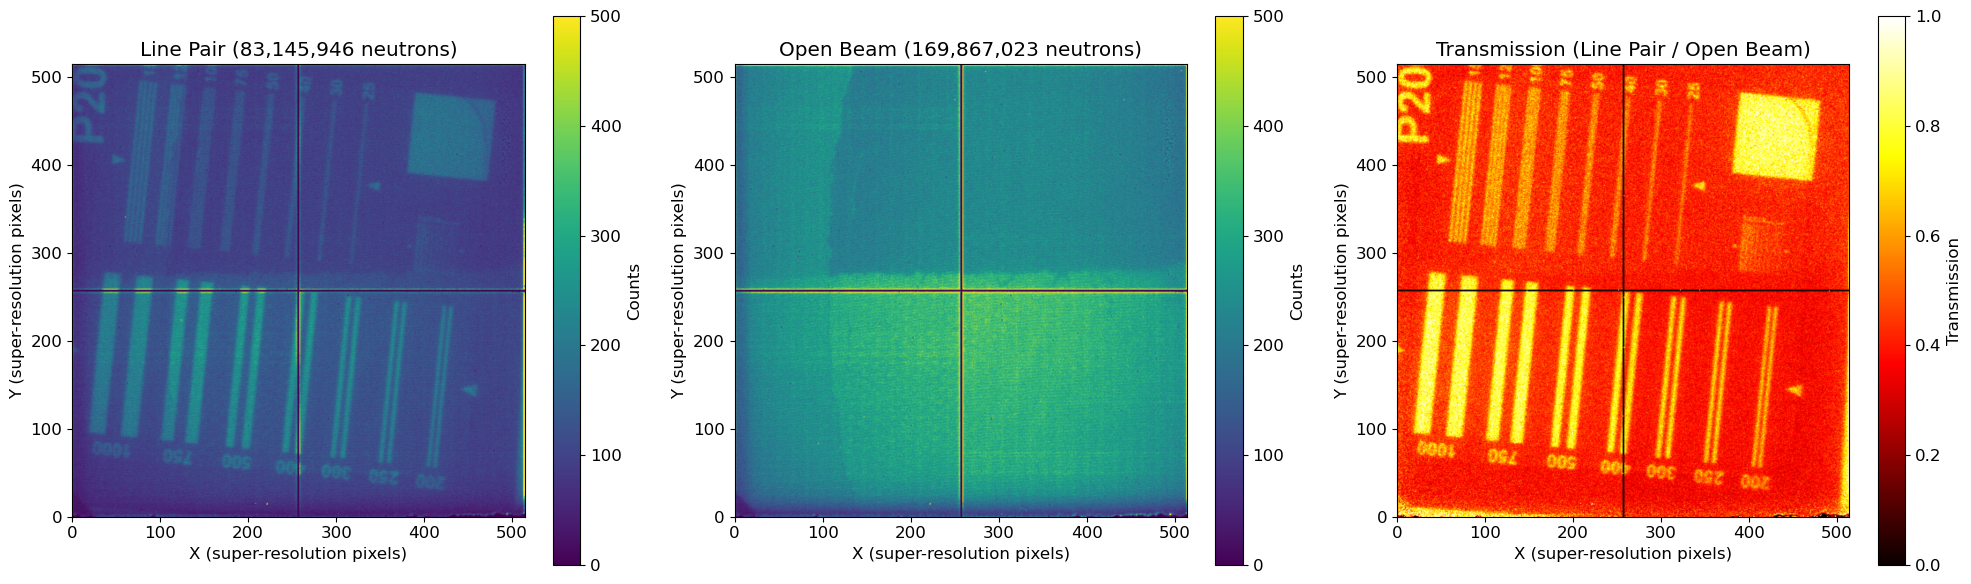


✅ Transmission image displayed


In [22]:
# Visualize linepair, Open Beam, and Transmission images
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Linepair image
im1 = axes[0].imshow(
    linepair_hist,
    origin="lower",
    aspect="equal",
    extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
    cmap="viridis",
    interpolation="gaussian",
    vmax=500
)
axes[0].set_xlabel("X (super-resolution pixels)")
axes[0].set_ylabel("Y (super-resolution pixels)")
axes[0].set_title(f"Line Pair ({len(linepair_neutrons):,} neutrons)")
plt.colorbar(im1, ax=axes[0], label="Counts")

# Open Beam image
im2 = axes[1].imshow(
    hist_ob,
    origin="lower",
    aspect="equal",
    extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
    cmap="viridis",
    interpolation="gaussian",
    vmax=500
)
axes[1].set_xlabel("X (super-resolution pixels)")
axes[1].set_ylabel("Y (super-resolution pixels)")
axes[1].set_title(f"Open Beam ({len(ob_neutrons):,} neutrons)")
plt.colorbar(im2, ax=axes[1], label="Counts")

# Transmission image
im3 = axes[2].imshow(
    transmission,
    origin="lower",
    aspect="equal",
    extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
    cmap="hot",
    interpolation="gaussian",
    vmin=0,
    vmax=1)  # use 99th percentile for better contrast

axes[2].set_xlabel("X (super-resolution pixels)")
axes[2].set_ylabel("Y (super-resolution pixels)")
axes[2].set_title("Transmission (Line Pair / Open Beam)")
plt.colorbar(im3, ax=axes[2], label="Transmission")

plt.tight_layout()
plt.show()

print(f"\n✅ Transmission image displayed")